# 03 - US-Only Exploratory Data Analysis

**Purpose:** Filter the combined dataset to US job postings only and reproduce all exploratory analysis for the collaborator presentation.

**Input:** `../data/processed/combined_dataset.parquet`  
**Output:** Charts saved to `results/week3/`, US summary statistics printed  

## Step 1: Import Libraries & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Chart styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Custom color palette
BLUE = '#2E86AB'
PURPLE = '#A23B72'
ORANGE = '#F18F01'
DARK_TEXT = '#1E293B'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#E2E8F0',
    'axes.grid': True,
    'grid.color': '#E2E8F0',
    'grid.alpha': 0.5,
    'text.color': DARK_TEXT,
})

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2: Load Combined Dataset

In [32]:
df = pd.read_parquet('../data/processed/combined_dataset.parquet')

print("=" * 60)
print("FULL DATASET LOADED")
print("=" * 60)
print(f"Total jobs: {len(df):,}")
print(f"Date range: {df['created'].min()} to {df['created'].max()}")
print(f"Countries: {df['country'].nunique()}")
print(f"Categories: {df['category'].nunique()}")

FULL DATASET LOADED
Total jobs: 127,281
Date range: 2012-01-08 07:55:00 to 2025-09-30 21:38:00
Countries: 134
Categories: 3


## Step 3: Filter to US-Only

Filter the full dataset to only include US job postings (`country == 'USA'`).

In [4]:
df_us = df[df['country'] == 'USA'].copy()

print("=" * 60)
print("US-ONLY FILTER APPLIED")
print("=" * 60)
print(f"US jobs: {len(df_us):,} ({len(df_us)/len(df)*100:.1f}% of total)")
print(f"Date range: {df_us['created'].min()} to {df_us['created'].max()}")
print(f"Categories: {df_us['category'].nunique()}")

# Verify no nulls in key fields after filter
print(f"\nKey field check (US only):")
for field in ['job_hash', 'title', 'company_name', 'created', 'category', 'job_description']:
    missing = df_us[field].isna().sum()
    pct = (missing / len(df_us)) * 100
    status = "True" if missing == 0 else "⚠️"
    print(f"  {status} {field}: {missing:,} missing ({pct:.1f}%)")

print(f"\nOptional field coverage (US only):")
for field in ['city', 'state', 'remote_detail', 'fulltime_parttime']:
    if field in df_us.columns:
        present = df_us[field].notna().sum()
        pct = (present / len(df_us)) * 100
        print(f"  {field}: {present:,} / {len(df_us):,} ({pct:.1f}%)")

US-ONLY FILTER APPLIED
US jobs: 74,309 (58.4% of total)
Date range: 2012-01-08 07:55:00 to 2025-09-30 21:38:00
Categories: 3

Key field check (US only):
  True job_hash: 0 missing (0.0%)
  True title: 0 missing (0.0%)
  True company_name: 0 missing (0.0%)
  True created: 0 missing (0.0%)
  True category: 0 missing (0.0%)
  True job_description: 0 missing (0.0%)

Optional field coverage (US only):
  city: 73,713 / 74,309 (99.2%)
  state: 73,691 / 74,309 (99.2%)
  remote_detail: 10,255 / 74,309 (13.8%)
  fulltime_parttime: 28,690 / 74,309 (38.6%)


## Step 4: Create Output Directory

In [34]:
Path('results/week3').mkdir(parents=True, exist_ok=True)
print("Output directory: results/week3/")

Output directory: results/week3/


## Step 5: US Category Distribution

How are the 3 job categories distributed within US postings?

In [35]:
print("=" * 60)
print("US CATEGORY DISTRIBUTION")
print("=" * 60)

us_category_counts = df_us['category'].value_counts()
print(us_category_counts)
print(f"\nPercentages:")
for cat, count in us_category_counts.items():
    print(f"  {cat}: {count:,} ({count/len(df_us)*100:.1f}%)")

Path('results/week3').mkdir(parents=True, exist_ok=True)

US CATEGORY DISTRIBUTION
category
urban_regional_planning     55748
transportation_engineers    17146
transportation_planners      1415
Name: count, dtype: int64

Percentages:
  urban_regional_planning: 55,748 (75.0%)
  transportation_engineers: 17,146 (23.1%)
  transportation_planners: 1,415 (1.9%)


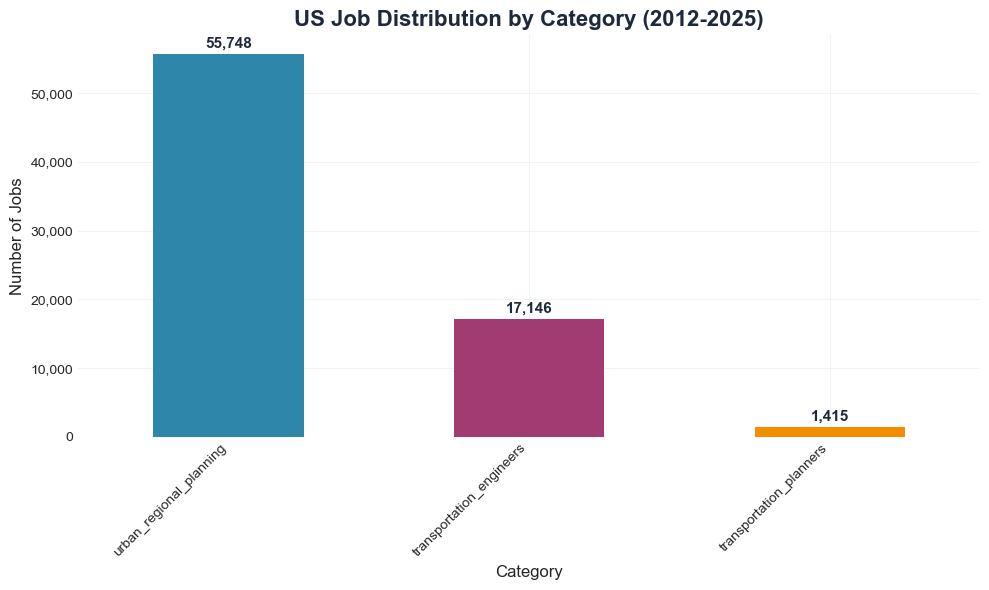

Chart 1 saved


In [59]:
# Chart 1: US Category Distribution
plt.figure(figsize=(10, 6))
colors = [BLUE, PURPLE, ORANGE]
ax = us_category_counts.plot(kind='bar', color=colors)
plt.title('US Job Distribution by Category (2012-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(us_category_counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/week3/01_us_jobs_by_category.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

## Chart Interpretation

The U.S. subset shows the same kind of imbalance as the full dataset, but transportation engineers make up a slightly bigger share here (23.1% in the U.S. vs 18.9% overall). Urban/regional planning is still the largest group at around 75%, and transportation planners are still the smallest group with only 1,415 postings.

This seems reasonable because the U.S. has a huge transportation and infrastructure system, so it likely needs more engineering-focused roles than some other countries. But since the transportation planners group is so small, we should be careful when comparing categories — things like statistical tests or machine learning models might not perform well with such an imbalanced class.

## Step 6: US Temporal Trends

How has the volume of US job postings changed year-over-year?

In [37]:
df_us['year'] = pd.to_datetime(df_us['created']).dt.year
us_jobs_by_year = df_us['year'].value_counts().sort_index()

print("=" * 60)
print("US JOBS BY YEAR")
print("=" * 60)
print(us_jobs_by_year.to_string())

US JOBS BY YEAR
year
2012        5
2013       28
2014      988
2015     2049
2016     3311
2017     5639
2018     5131
2019     6184
2020     4245
2021     7038
2022     9690
2023    10248
2024    12249
2025     7504


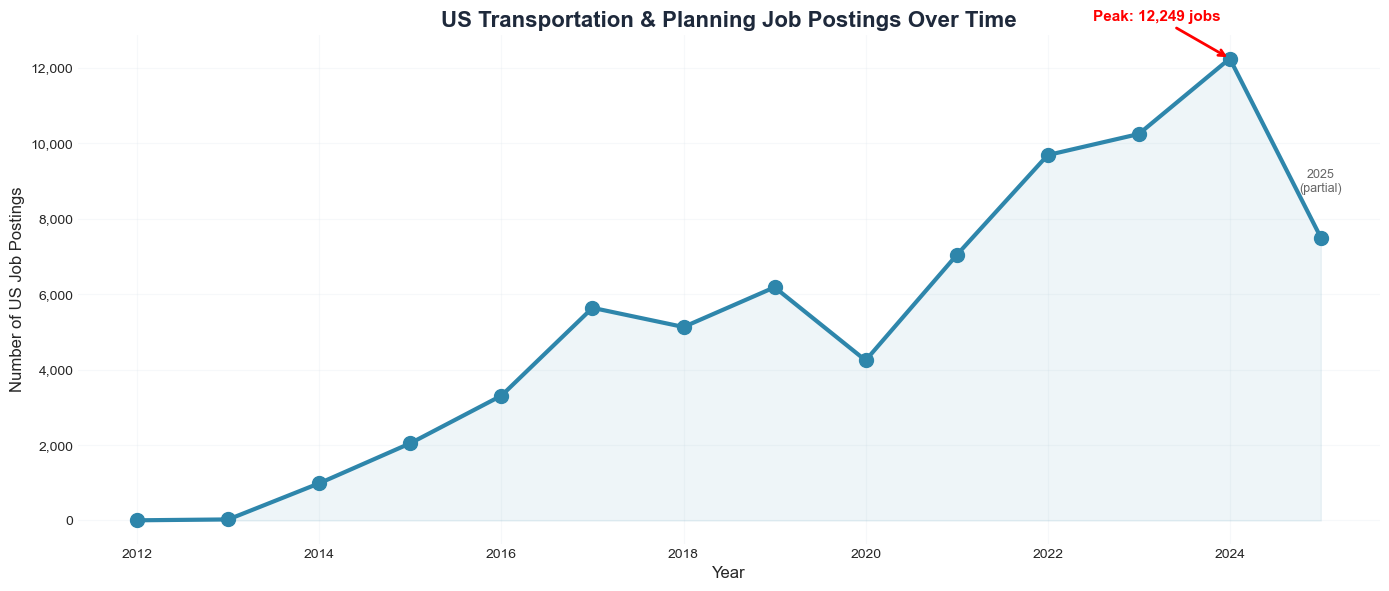

Chart 2 saved


In [58]:
# Chart 2: US Overall Temporal Trend
plt.figure(figsize=(14, 6))
plt.plot(us_jobs_by_year.index, us_jobs_by_year.values, marker='o', linewidth=3,
         markersize=10, color=BLUE)
plt.fill_between(us_jobs_by_year.index, us_jobs_by_year.values, alpha=0.08, color=BLUE)
plt.title('US Transportation & Planning Job Postings Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of US Job Postings', fontsize=12)
plt.grid(True, alpha=0.3)

# Annotate peak
max_year = us_jobs_by_year.idxmax()
max_jobs = us_jobs_by_year.max()
plt.annotate(f'Peak: {max_jobs:,} jobs',
             xy=(max_year, max_jobs),
             xytext=(max_year - 1.5, max_jobs + 1000),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, fontweight='bold', color='red')

# Mark 2025 as partial year
if 2025 in us_jobs_by_year.index:
    plt.annotate('2025\n(partial)',
                 xy=(2025, us_jobs_by_year.get(2025, 0)),
                 xytext=(2025, us_jobs_by_year.get(2025, 0) + 1200),
                 fontsize=9, ha='center', color='#666')

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/week3/02_us_jobs_over_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

## Chart Interpretation

One of the more surprising findings here: the US peak is in 2024 (12,249 jobs), not 2021 like the global dataset. This suggests different dynamics are driving US hiring vs the rest of the world. The 2020 dip lines up with COVID, but recovery has been stronger and more sustained in the US, possibly driven by the Infrastructure Investment and Jobs Act (IIJA) signed in late 2021. The effects of that legislation seem to show up in 2022-2024 as federal funding started flowing to state and local agencies. 2025 is partial data (through September) so the drop-off is expected.
Worth noting that 2012 and 2013 have very few records (5 and 28 respectively), which probably reflects LinkUp's data coverage ramping up rather than actual market size.

## Step 7: US Category Trends Over Time

Breaking down the yearly trend by each of the three categories.

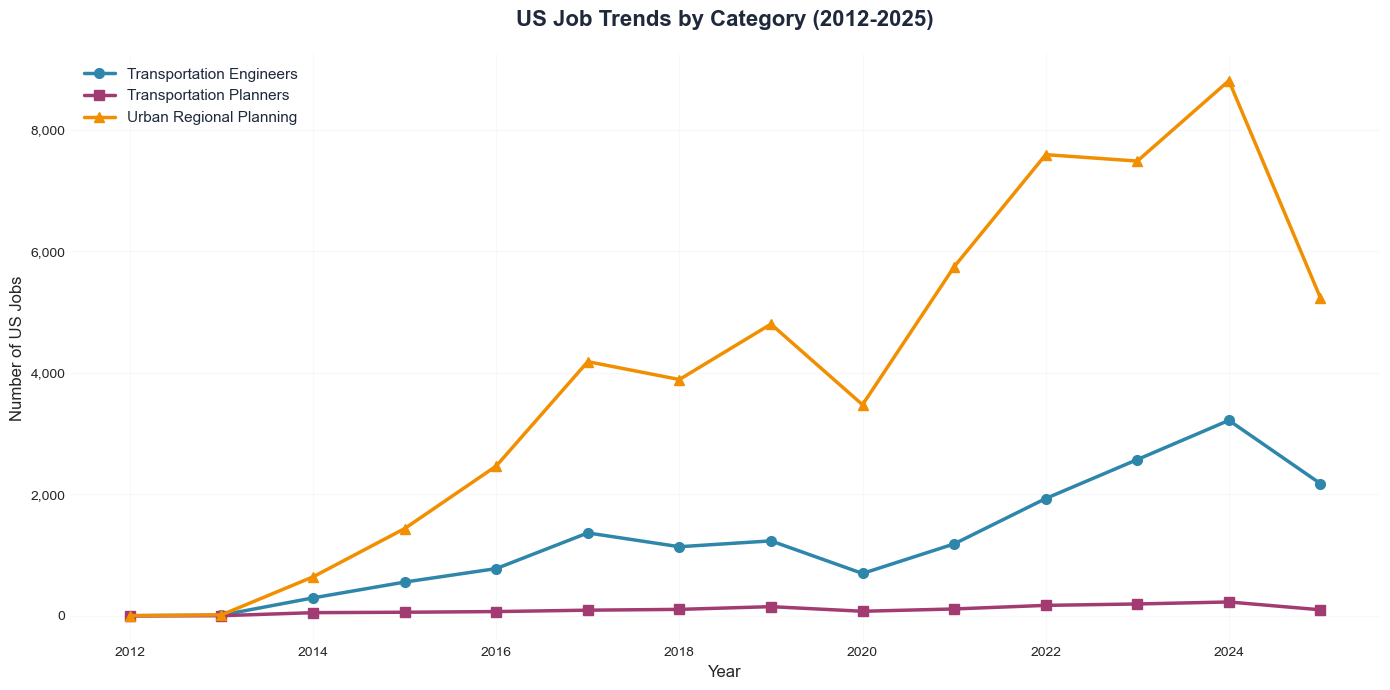

Chart 3 saved

US Category Trends (yearly counts):
category  transportation_engineers  transportation_planners  urban_regional_planning
year                                                                                
2012                             2                        0                        3
2013                            11                        2                       15
2014                           295                       52                      641
2015                           555                       59                     1435
2016                           777                       70                     2464
2017                          1364                       93                     4182
2018                          1137                      106                     3888
2019                          1233                      151                     4800
2020                           697                       75                     3473
2021          

In [57]:
us_pivot = df_us.groupby(['year', 'category']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
markers = ['o', 's', '^']
colors_list = [BLUE, PURPLE, ORANGE]

for i, category in enumerate(us_pivot.columns):
    plt.plot(us_pivot.index, us_pivot[category],
             marker=markers[i % len(markers)], linewidth=2.5, markersize=7,
             color=colors_list[i % len(colors_list)],
             label=category.replace('_', ' ').title())

plt.title('US Job Trends by Category (2012-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of US Jobs', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/week3/03_us_category_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

# Print category trend summary
print("\nUS Category Trends (yearly counts):")
print(us_pivot.to_string())

## Chart Interpretation

All three categories show growth from 2014 onward, but the patterns differ. Urban/regional planning is the most volatile — it dipped in 2020, recovered, and then saw its biggest jump in 2022-2024. Transportation engineers have been on a pretty steady upward climb, especially post-2020, which makes sense given the infrastructure spending push. Transportation planners remain flat throughout, staying under 250 jobs per year. This category might just be too niche to show meaningful trends, or it could be that these roles get classified under different titles by some employers.

## Step 8: Top US Employers

Which companies post the most planning and transportation jobs in the US?

In [40]:
print("=" * 60)
print("TOP US EMPLOYERS")
print("=" * 60)

us_top_companies = df_us['company_name'].value_counts().head(15)
print(us_top_companies.to_string())

# Note about AECOM duplicates
aecom_variants = df_us[df_us['company_name'].str.contains('AECOM|Aecom|aecom', case=False, na=False)]
print(f"\nAECOM variant check:")
print(aecom_variants['company_name'].value_counts().to_string())
print(f"Total AECOM (all variants): {len(aecom_variants):,}")

TOP US EMPLOYERS
company_name
State of California                 2366
AECOM                               1999
HNTB Corporation                    1828
Kimley-Horn and Associates, Inc.    1804
US Department of Transportation     1592
Aecom Technology Corporation        1362
International City Management       1164
WSP                                 1123
HDR, Inc.                           1106
Vanasse Hangen Brustlin             1099
Stantec Inc.                        1045
Minnesota City Jobs                  818
State of Michigan                    784
Jones Lange Lasalle Inc.             775
Actalent                             670

AECOM variant check:
company_name
AECOM                           1999
Aecom Technology Corporation    1362
Total AECOM (all variants): 3,361


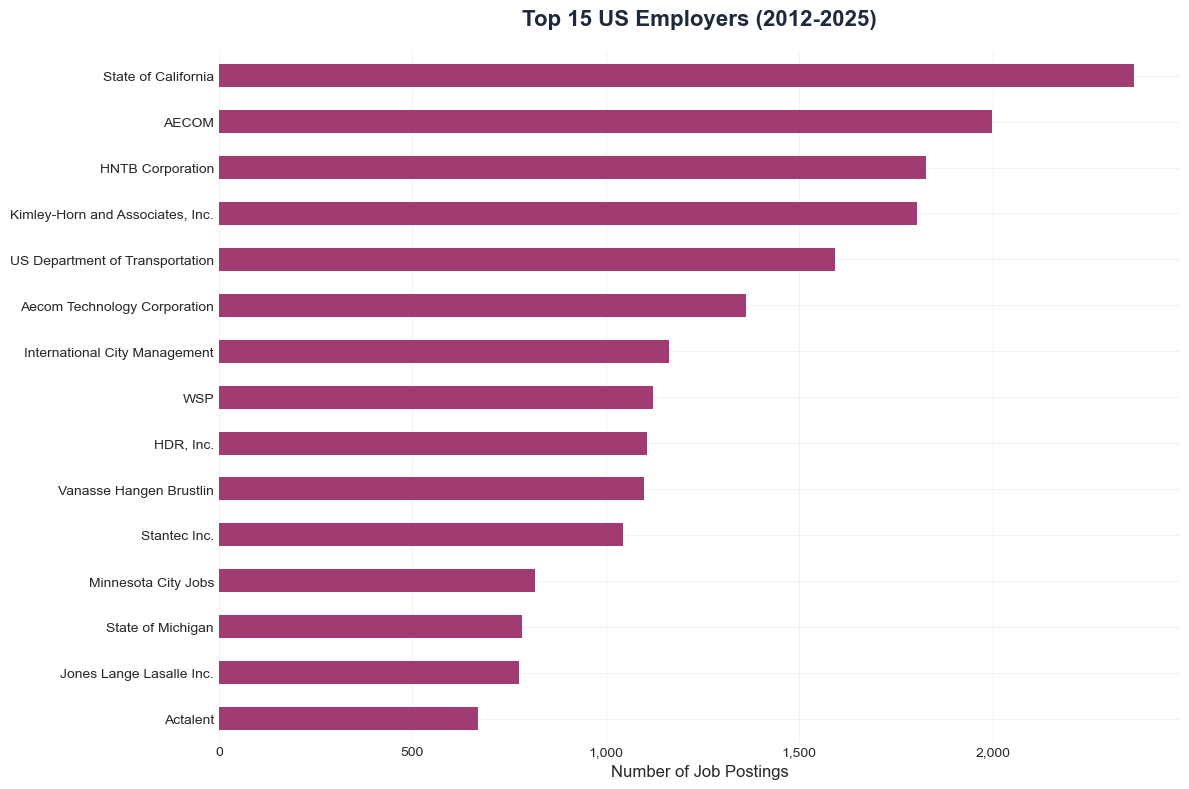

Chart 4 saved


In [56]:
# Chart 4: Top US Employers
plt.figure(figsize=(12, 8))
us_top_companies.plot(kind='barh', color=PURPLE)
plt.title('Top 15 US Employers (2012-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('')
plt.gca().invert_yaxis()

ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/week3/04_us_top_companies.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

## Chart Interpretation

State of California leads with 2,366 postings, which isn't surprising given CA's size and the amount of state-level planning work (Caltrans alone is massive). AECOM shows up twice : — "AECOM" (1,999) and "Aecom Technology Corporation" (1,362) — totaling 3,361 combined. This is a data quality issue we flagged in Notebook 1 and still needs to be cleaned.
The top employers are mostly large engineering/consulting firms (HNTB, Kimley-Horn, WSP, HDR, Stantec) plus government agencies (State of CA, US DOT, State of Michigan). "International City Management" is likely ICMA — a professional association that also posts planning jobs. The mix of private and public sector employers is interesting and could be worth analyzing further.

## Step 9: Top US Cities

Geographic distribution of job postings across US cities.

In [42]:
print("=" * 60)
print("TOP US CITIES")
print("=" * 60)

us_top_cities = df_us['city'].value_counts().head(20)
print(us_top_cities.to_string())

TOP US CITIES
city
sacramento       2013
austin           1374
atlanta          1284
new york         1040
denver           1023
houston           968
raleigh           948
los angeles       895
chicago           892
boston            840
seattle           795
orlando           742
washington        686
tampa             680
san francisco     675
dallas            673
portland          607
phoenix           589
san antonio       582
san diego         581


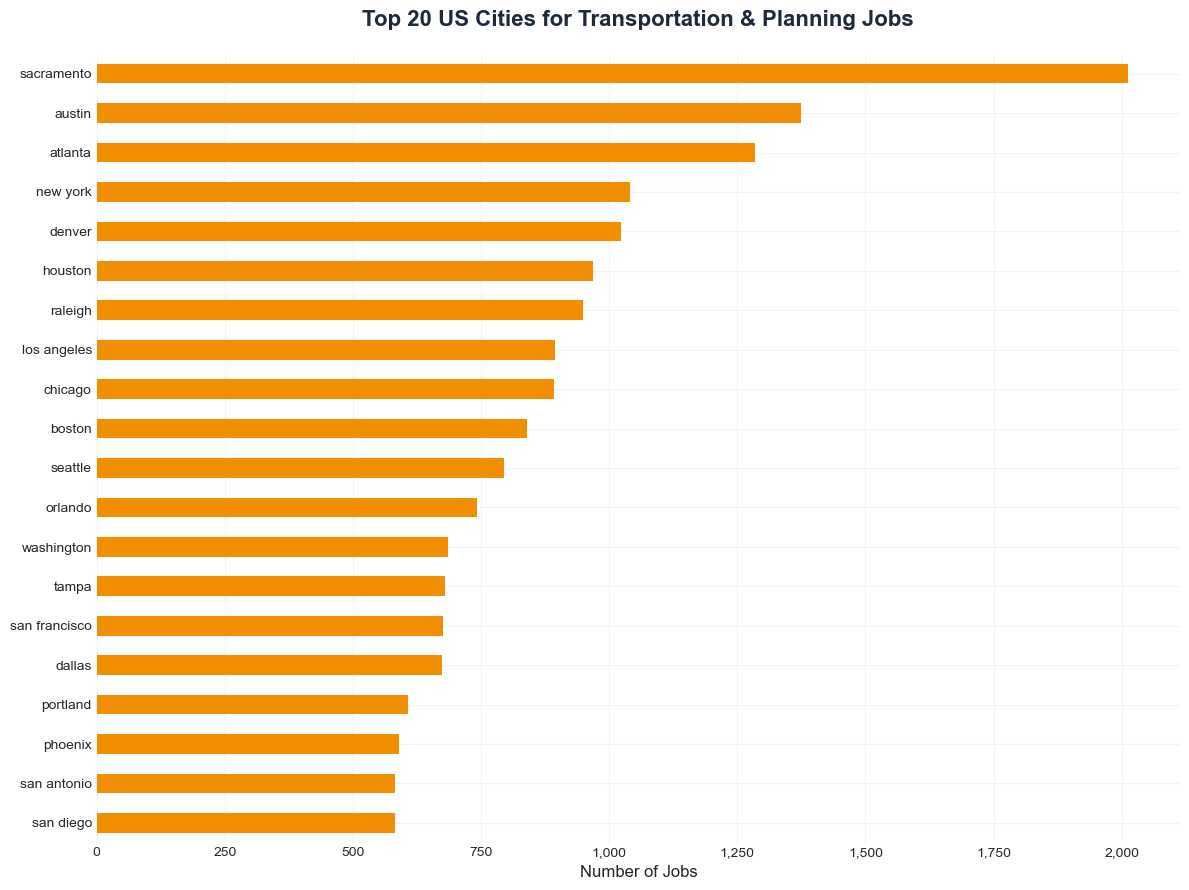

Chart 5 saved


In [55]:
# Chart 5: Top US Cities
plt.figure(figsize=(12, 9))
us_top_cities.plot(kind='barh', color=ORANGE)
plt.title('Top 20 US Cities for Transportation & Planning Jobs', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('')
plt.gca().invert_yaxis()

ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/week3/05_us_top_cities.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

## Chart Interpretation

Sacramento leads US cities (2,013), which aligns with it being California's capital and having heavy state government hiring. The rest of the top cities are a mix of Sun Belt metros (Austin, Atlanta, Houston, Orlando, Tampa, San Antonio, Phoenix) and traditional major cities (New York, Chicago, Boston, Seattle). The Sun Belt presence probably reflects the rapid population growth in those regions driving demand for planners and engineers.
All city names are lowercase in the data, confirming the casing inconsistency we identified earlier. This hasn't been standardized yet but since we're doing value_counts() it groups correctly for now.

## Step 10: Top US States

State-level distribution of job postings.

In [44]:
print("=" * 60)
print("TOP US STATES")
print("=" * 60)

us_top_states = df_us['state'].value_counts().head(15)
print(us_top_states.to_string())

TOP US STATES
state
CA    11825
TX     6949
FL     6723
VA     3622
NY     2864
CO     2825
WA     2750
NC     2739
GA     2345
MN     2310
MD     1947
MA     1864
IL     1818
PA     1779
MI     1772


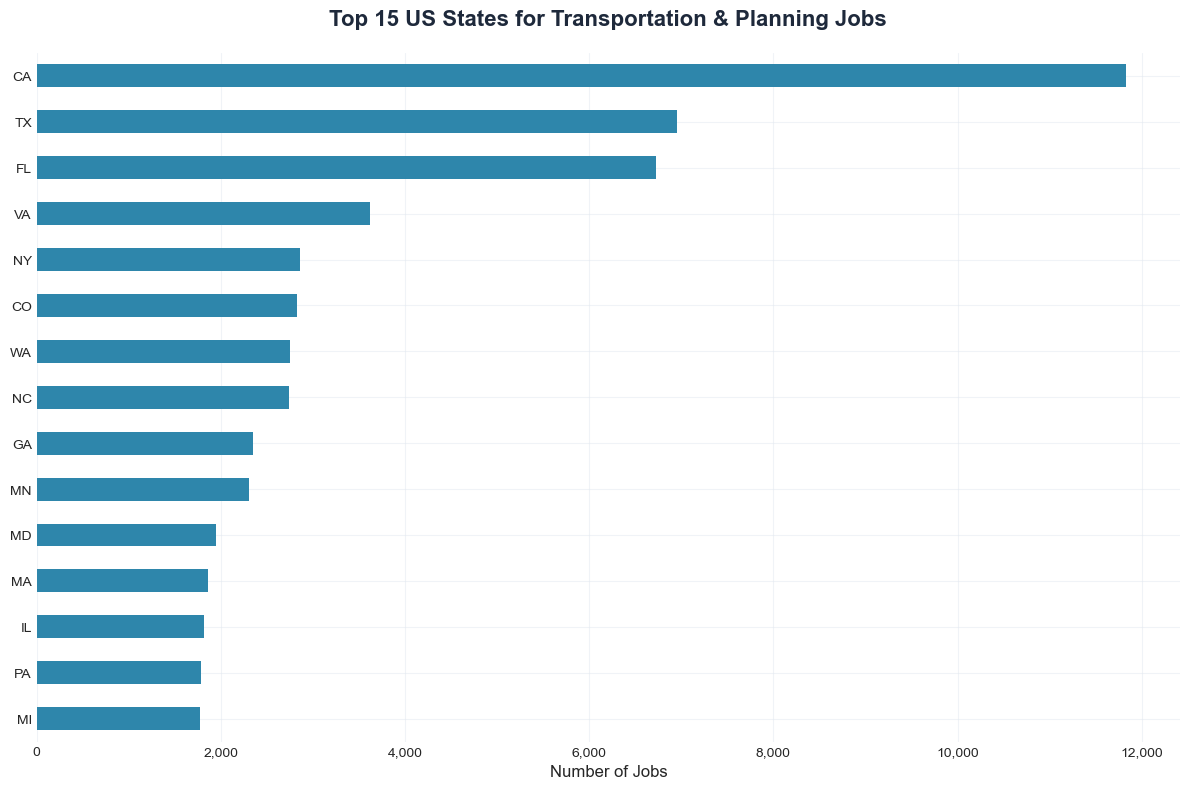

Chart 6 saved


In [54]:
# Chart 6: Top US States
plt.figure(figsize=(12, 8))
us_top_states.plot(kind='barh', color=BLUE)
plt.title('Top 15 US States for Transportation & Planning Jobs', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('')
plt.gca().invert_yaxis()

ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/week3/06_us_top_states.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

## Chart Interpretation

California dominates at 11,825 — nearly double the second-place state (Texas at 6,949). Florida is third at 6,723. The top 3 states alone account for about 34% of all US postings. The ranking generally follows state population and development activity. Virginia's 4th-place finish (3,622) is notable — it's probably driven by the DC metro area and the concentration of federal contractors and planning agencies there.
52 unique states in the data includes DC and likely some territories, which makes sense.

## Step 11: US Job Description Length Analysis

Understanding the text corpus available for NLP and skill extraction.

In [46]:
print("=" * 60)
print("US JOB DESCRIPTION LENGTH ANALYSIS")
print("=" * 60)

us_desc_lengths = df_us['job_description'].str.len()
print(f"Mean:   {us_desc_lengths.mean():,.0f} characters")
print(f"Median: {us_desc_lengths.median():,.0f} characters")
print(f"Min:    {us_desc_lengths.min():,} characters")
print(f"Max:    {us_desc_lengths.max():,} characters")
print(f"Std:    {us_desc_lengths.std():,.0f} characters")

# Stub analysis
stub_threshold = 100
stubs = (us_desc_lengths < stub_threshold).sum()
print(f"\nStub descriptions (<{stub_threshold} chars): {stubs:,} ({stubs/len(df_us)*100:.2f}%)")

US JOB DESCRIPTION LENGTH ANALYSIS
Mean:   5,540 characters
Median: 4,532 characters
Min:    1 characters
Max:    43,122 characters
Std:    4,393 characters

Stub descriptions (<100 chars): 594 (0.80%)


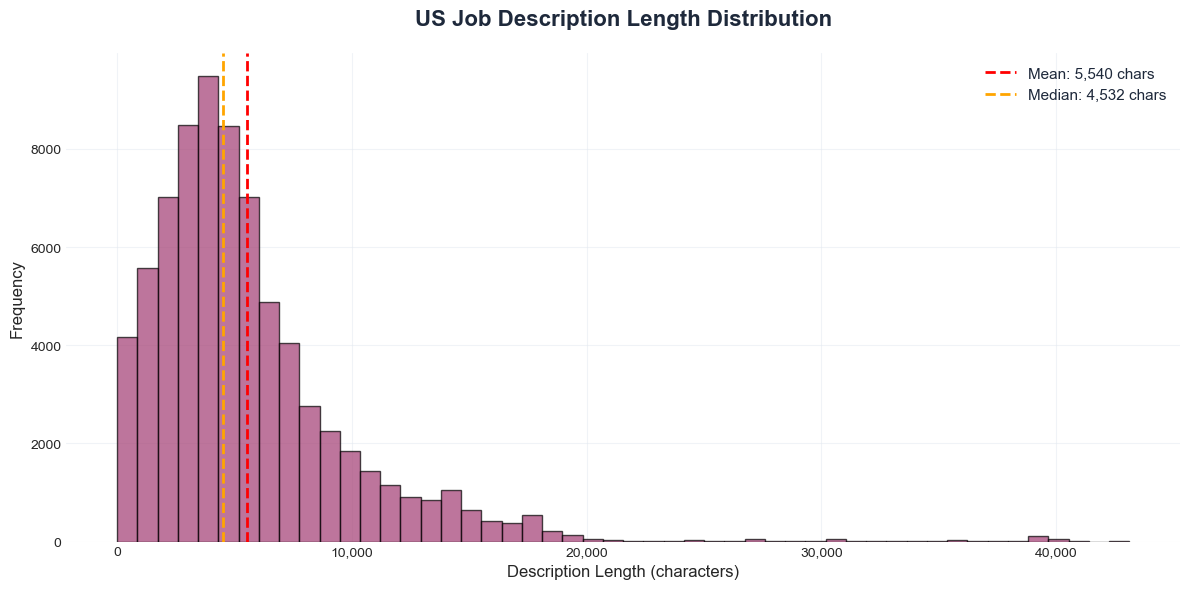

Chart 7 saved


In [47]:
# Chart 7: US Description Length Distribution
plt.figure(figsize=(12, 6))
plt.hist(us_desc_lengths, bins=50, color=PURPLE, alpha=0.7, edgecolor='black')
plt.axvline(us_desc_lengths.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {us_desc_lengths.mean():,.0f} chars')
plt.axvline(us_desc_lengths.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {us_desc_lengths.median():,.0f} chars')
plt.title('US Job Description Length Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Description Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)

ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/week3/07_us_description_lengths.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 7 saved")

## Chart Interpretation

US descriptions average 5,540 characters (slightly higher than the global mean of ~4,986), with a median of 4,532. The distribution is right-skewed as expected — most descriptions fall in the 2,000-8,000 character range, with a long tail of very detailed postings going up to 43,122 characters.
There are 594 stub descriptions under 100 characters (0.80%). These are likely placeholder or error postings and should be filtered out before doing any NLP work. Overall, the corpus is rich enough for skill extraction — at ~5,500 characters average, most postings contain detailed qualification and responsibility sections.

## Step 12: US Remote Work & Employment Type

Distribution of remote work tags and full-time/part-time classification among US postings.

In [48]:
print("=" * 60)
print("US REMOTE WORK DISTRIBUTION")
print("=" * 60)

if 'remote_detail' in df_us.columns:
    us_remote = df_us['remote_detail'].value_counts()
    us_remote_pct = df_us['remote_detail'].notna().sum()
    print(f"Jobs with remote info: {us_remote_pct:,} ({us_remote_pct/len(df_us)*100:.1f}%)")
    print(us_remote.to_string())

print("\n" + "=" * 60)
print("US EMPLOYMENT TYPE DISTRIBUTION")
print("=" * 60)

if 'fulltime_parttime' in df_us.columns:
    us_emp_type = df_us['fulltime_parttime'].value_counts()
    us_emp_pct = df_us['fulltime_parttime'].notna().sum()
    print(f"Jobs with employment type: {us_emp_pct:,} ({us_emp_pct/len(df_us)*100:.1f}%)")
    print(us_emp_type.to_string())

US REMOTE WORK DISTRIBUTION
Jobs with remote info: 10,255 (13.8%)
remote_detail
Hybrid    6233
Remote    4022

US EMPLOYMENT TYPE DISTRIBUTION
Jobs with employment type: 28,690 (38.6%)
fulltime_parttime
fulltime             22117
parttime              3537
fulltime_parttime     3036


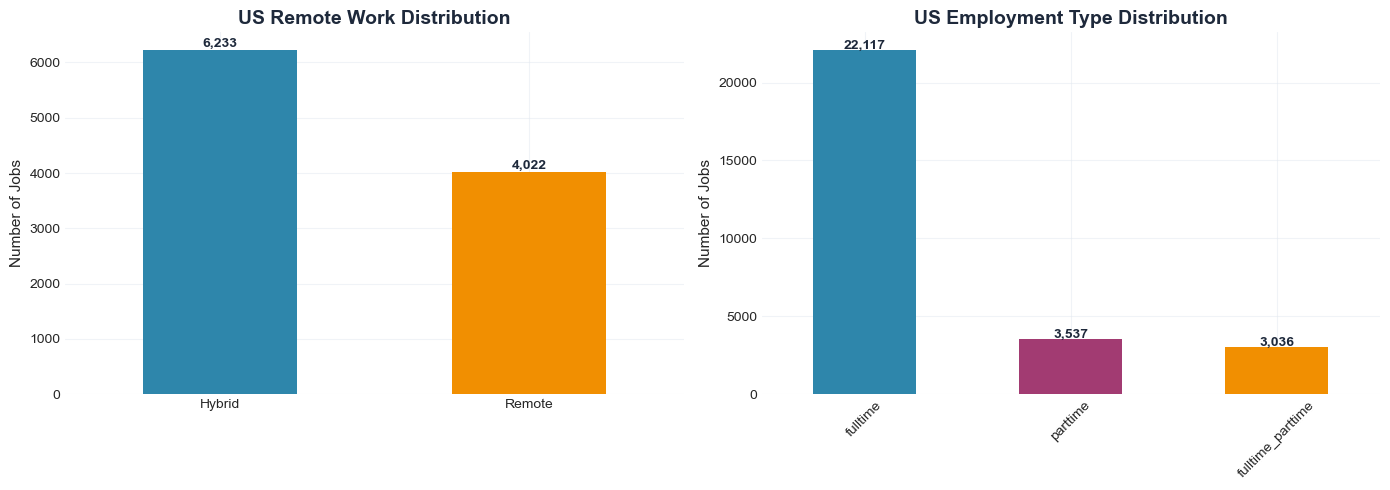

Chart 8 saved


In [49]:
# Chart 8: Remote work and employment type side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if 'remote_detail' in df_us.columns and df_us['remote_detail'].notna().any():
    us_remote.plot(kind='bar', ax=ax1, color=[BLUE, ORANGE])
    ax1.set_title('US Remote Work Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylabel('Number of Jobs', fontsize=11)
    ax1.tick_params(axis='x', rotation=0)
    for i, v in enumerate(us_remote):
        ax1.text(i, v + 50, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

if 'fulltime_parttime' in df_us.columns and df_us['fulltime_parttime'].notna().any():
    us_emp_type.plot(kind='bar', ax=ax2, color=[BLUE, PURPLE, ORANGE])
    ax2.set_title('US Employment Type Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('')
    ax2.set_ylabel('Number of Jobs', fontsize=11)
    ax2.tick_params(axis='x', rotation=45)
    for i, v in enumerate(us_emp_type):
        ax2.text(i, v + 50, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/week3/08_us_remote_employment.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 8 saved")

## Chart Interpretation

Remote work data is sparse — only 13.8% of US postings have this field populated. Of those, Hybrid (6,233) outnumbers fully Remote (4,022) by about 60/40. This is consistent with the nature of planning and engineering work, where site visits and in-person collaboration are often needed.
Employment type coverage is better at 38.6%. Fulltime dominates (22,117), with part-time (3,537) and a "fulltime_parttime" mixed category (3,036). The mixed category might represent positions offering flexible arrangements or could be a data quality quirk.
Since both fields are so sparse, any analysis of remote or employment trends over time would need to account for increasing data coverage — what looks like a "trend" might just be more employers populating these fields in recent years.

## Step 13: US O*NET Code Distribution

Which O*NET occupation codes are most common among US postings?

In [50]:
print("=" * 60)
print("US O*NET CODE DISTRIBUTION")
print("=" * 60)

if 'onet_occupation_code' in df_us.columns:
    us_onet = df_us['onet_occupation_code'].value_counts().head(10)
    print(us_onet.to_string())

    # Add description if available
    if 'onet_occupation_code_desc' in df_us.columns:
        print("\nTop O*NET codes with descriptions:")
        onet_desc = df_us.groupby(['onet_occupation_code', 'onet_occupation_code_desc']).size()
        onet_desc = onet_desc.reset_index(name='count').sort_values('count', ascending=False).head(10)
        for _, row in onet_desc.iterrows():
            print(f"  {row['onet_occupation_code']} - {row['onet_occupation_code_desc']}: {row['count']:,}")

US O*NET CODE DISTRIBUTION
onet_occupation_code
19-3051.00    55748
17-2051.01    17146
19-3099.01     1415

Top O*NET codes with descriptions:
  19-3051.00 - 19-3051.00: 55,748
  17-2051.01 - 17-2051.01: 17,146
  19-3099.01 - 19-3099.01: 1,415


## Step 14: US Demand Analysis — job_hash vs base_hash

The same job opening can be posted in multiple cities. Each city-level posting gets its own `job_hash`, 
but they share the same `base_hash`. This step quantifies the difference for accurate demand counts.

In [51]:
print("=" * 60)
print("DEMAND ANALYSIS: job_hash vs base_hash (US)")
print("=" * 60)

us_unique_postings = df_us['job_hash'].nunique()
us_unique_openings = df_us['base_hash'].nunique()
us_multi_location = us_unique_postings - us_unique_openings

print(f"Unique postings (job_hash): {us_unique_postings:,}")
print(f"Unique openings (base_hash): {us_unique_openings:,}")
print(f"Multi-location duplicates: {us_multi_location:,}")
print(f"Average postings per opening: {us_unique_postings/us_unique_openings:.2f}")
print(f"\nNote: Use base_hash for demand counts, job_hash for geographic analysis.")

DEMAND ANALYSIS: job_hash vs base_hash (US)
Unique postings (job_hash): 74,309
Unique openings (base_hash): 66,831
Multi-location duplicates: 7,478
Average postings per opening: 1.11

Note: Use base_hash for demand counts, job_hash for geographic analysis.


## Interpretation

Out of 74,309 location-level postings (job_hash), there are 66,831 unique job openings (base_hash). That means about 7,478 postings (~10%) are the same job listed in multiple cities. The ratio of 1.11 postings per opening is relatively low, meaning most US jobs are posted in a single location. For demand-side analysis (how many actual jobs exist), we should use base_hash counts. For geographic analysis (where are jobs posted), job_hash is the right identifier.

## Step 15: Final US-Only Summary

In [52]:
us_desc_lengths = df_us['job_description'].str.len()
us_unique_openings = df_us['base_hash'].nunique()

print("=" * 60)
print("FINAL US-ONLY SUMMARY")
print("=" * 60)
print(f"{'Metric':<40} {'Value':>15}")
print("-" * 57)
print(f"{'Total US job postings':<40} {len(df_us):>15,}")
print(f"{'Unique job openings (base_hash)':<40} {us_unique_openings:>15,}")
print(f"{'Date range':<40} {'2012 - 2025':>15}")
print(f"{'Categories':<40} {df_us['category'].nunique():>15}")
print(f"{'Unique companies':<40} {df_us['company_name'].nunique():>15,}")
print(f"{'Unique cities':<40} {df_us['city'].nunique():>15,}")
print(f"{'Unique states':<40} {df_us['state'].nunique():>15,}")
print(f"{'Avg description length':<40} {us_desc_lengths.mean():>15,.0f}")
print(f"{'Jobs with remote info':<40} {df_us['remote_detail'].notna().sum():>15,}")
print(f"{'Jobs with employment type':<40} {df_us['fulltime_parttime'].notna().sum():>15,}")

FINAL US-ONLY SUMMARY
Metric                                             Value
---------------------------------------------------------
Total US job postings                             74,309
Unique job openings (base_hash)                   66,831
Date range                                   2012 - 2025
Categories                                             3
Unique companies                                   3,606
Unique cities                                      3,271
Unique states                                         52
Avg description length                             5,540
Jobs with remote info                             10,255
Jobs with employment type                         28,690


## Step 16: Save US-Only Dataset

Save the filtered US dataset as a separate parquet file for future analysis.

In [53]:
us_output_path = '../data/processed/us_only_dataset.parquet'
df_us.to_parquet(us_output_path, index=False)
us_file_size = Path(us_output_path).stat().st_size / 1_000_000
print(f"US-only dataset saved: {us_output_path}")
print(f"  File size: {us_file_size:.1f} MB")
print(f"  Shape: {df_us.shape[0]:,} rows × {df_us.shape[1]} columns")

print("\n" + "=" * 60)
print("US-ONLY EDA COMPLETE")
print("=" * 60)
print(f"\nCharts saved to: results/week3/")
print(f"US dataset saved to: {us_output_path}")
print(f"\nFiles created:")
print(f"   01_us_jobs_by_category.png")
print(f"   02_us_jobs_over_time.png")
print(f"   03_us_category_trends.png")
print(f"   04_us_top_companies.png")
print(f"   05_us_top_cities.png")
print(f"   06_us_top_states.png")
print(f"   07_us_description_lengths.png")
print(f"   08_us_remote_employment.png")
print(f"   us_only_dataset.parquet")

US-only dataset saved: ../data/processed/us_only_dataset.parquet
  File size: 218.2 MB
  Shape: 74,309 rows × 23 columns

US-ONLY EDA COMPLETE

Charts saved to: results/week3/
US dataset saved to: ../data/processed/us_only_dataset.parquet

Files created:
   01_us_jobs_by_category.png
   02_us_jobs_over_time.png
   03_us_category_trends.png
   04_us_top_companies.png
   05_us_top_cities.png
   06_us_top_states.png
   07_us_description_lengths.png
   08_us_remote_employment.png
   us_only_dataset.parquet
